# 3. The forward problem: Jacobi vs Gauss-Seidel vs AB2

Message passing is not tied to estimation. `System.simulate` solves the coupled
*direct* problem with the same schedules and no filters, which is the cleanest way
to see what a schedule costs in accuracy. We compare three schedules against the
monolithic 4-DOF model:

- **Jacobi**: every subsystem uses its neighbours' interface variables from the
  previous step and all subsystems advance in parallel.
- **Gauss-Seidel**: subsystems advance one after another and use the most recent
  values of the neighbours already updated.
- **AB2**: parallel like Jacobi, with the neighbours' interface variables
  extrapolated to the middle of the step (Adams-Bashforth 2).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pci

SCHEDULES = ["jacobi", "gauss_seidel", "ab2"]

## Monolithic reference

In [2]:
chain = pci.MassSpringChain.uniform(4, mass=500.0, k=50_000.0, c=300.0)
dt, T = 1e-3, 5.0
loads = {d: {"type": "random", "std": 50.0, "seed": 123 + d} for d in range(1, 5)}
truth = chain.simulate(loads, dt=dt, T=T, x0={"x1": 0.01, "v1": 0.01}, integrator="heun")
port_loads = {f"f{d}": v for d, v in loads.items()}

## Decomposed simulation with each schedule

The same partition as in the quickstart, no sensors and no unknowns. `Results.rmse`
compares the decomposed trajectories with the monolithic ones.

       jacobi: RMSE vs monolithic {'x1': '2.36e-05', 'x2': '2.55e-05', 'x3': '1.48e-05', 'x4': '2.11e-05'}
 gauss_seidel: RMSE vs monolithic {'x1': '2.56e-05', 'x2': '2.73e-05', 'x3': '2.68e-05', 'x4': '3.33e-05'}


          ab2: RMSE vs monolithic {'x1': '1.38e-08', 'x2': '1.54e-08', 'x3': '9.25e-09', 'x4': '1.25e-08'}


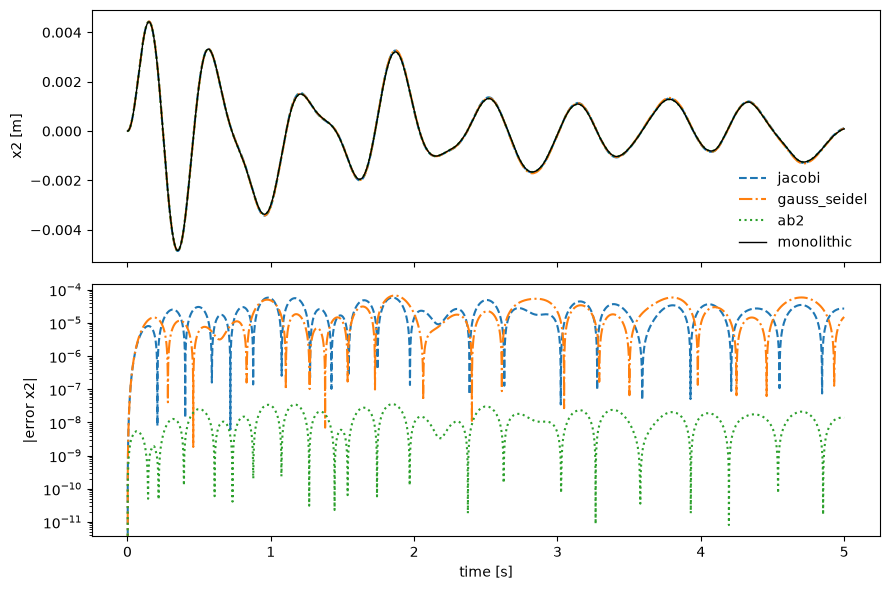

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for schedule, style in zip(SCHEDULES, ["--", "-.", ":"]):
    system = chain.decompose([[1, 2], [3, 4]], integrator="heun", schedule=schedule, x0={"x1": 0.01, "v1": 0.01})
    res = system.simulate(loads=port_loads, dt=dt, T=T, truth=truth.as_dict())
    err = res.rmse(["x1", "x2", "x3", "x4"])
    print(f"{schedule:>13s}: RMSE vs monolithic", {k: f"{v:.2e}" for k, v in err.items()})
    axes[0].plot(res.t, res["x2"], style, label=schedule)
    axes[1].plot(res.t, np.abs(res.errors("x2")), style, label=schedule)
axes[0].plot(truth.t, truth.signal("x2"), "k", lw=1, label="monolithic")
axes[0].set_ylabel("x2 [m]"); axes[0].legend(frameon=False)
axes[1].set_ylabel("|error x2|"); axes[1].set_yscale("log"); axes[1].set_xlabel("time [s]")
fig.tight_layout()

Gauss-Seidel halves the lag of the coupling for the subsystem updated second; AB2
removes most of it for both. The forward errors are small compared with the
measurement noise of the estimation examples, which is why all three schedules give
the same parameter estimates there.

## The YAML twin

`03_forward.yaml` sets `mode: simulate`. Overriding its `schedule` key reproduces
the loop above.

In [4]:
cfg = pci.load_config("03_forward.yaml")
for schedule in SCHEDULES:
    cfg["schedule"] = schedule
    res = pci.solve(cfg)
    print(f"YAML {schedule:>13s}: mean x-RMSE vs monolithic {np.mean(list(res.rmse(['x1', 'x2', 'x3', 'x4']).values())):.2e}")

YAML        jacobi: mean x-RMSE vs monolithic 2.13e-05
YAML  gauss_seidel: mean x-RMSE vs monolithic 2.82e-05


YAML           ab2: mean x-RMSE vs monolithic 1.27e-08
